In [1]:
%matplotlib widget

# Perform Piecewise Inversion on Field data: Ackerdijkse Plassen

In [2]:
import numpy as np
import pygimli as pg
import empymod as ep
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import sys
sys.path.insert(1, 'src')

from FDEM1D import FDEM1DModelling_field
from showStitched import showStitchedModels

/tmp/ipykernel_3284619/658363837.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
# 1. Load data

Dataframe = pd.DataFrame(np.load('data/Field_data.npy'),
                        columns = ['X','Y','Position','Z','H2Q','H4Q','H8Q',
                                   'V2Q','V4Q','V8Q','P2Q','P4Q','P8Q',
                                   'H4IP','H8IP','V4IP','V8IP'])

In [4]:
Dataframe

,X,Y,Position,Z,H2Q,H4Q,H8Q,V2Q,V4Q,V8Q,P2Q,P4Q,P8Q,H4IP,H8IP,V4IP,V8IP
0,4.421889,51.975739,1.0,-2.675400,0.004598,0.022228,0.074302,0.002878,0.016571,0.077201,0.002742,0.017739,0.095344,0.006820,0.04980,0.002560,0.02815
1,4.421891,51.975745,2.0,-2.700714,0.004619,0.022143,0.073619,0.002928,0.016714,0.076178,0.002769,0.017963,0.095111,0.006755,0.04909,0.002630,0.02789
2,4.421893,51.975752,3.0,-2.748954,0.004676,0.022143,0.072880,0.002956,0.016685,0.076291,0.002875,0.018366,0.095694,0.006680,0.05008,0.002640,0.02762
3,4.421895,51.975758,4.0,-2.782702,0.004690,0.022086,0.072426,0.002985,0.016742,0.076405,0.002961,0.018515,0.095927,0.006790,0.04988,0.002610,0.02781
4,4.421897,51.975765,5.0,-2.852704,0.004722,0.022200,0.072823,0.003148,0.017225,0.076973,0.003067,0.018784,0.095986,0.006835,0.04946,0.002550,0.02729
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1845,4.422503,51.975986,46.0,-3.128721,0.003674,0.018419,0.069242,0.003198,0.016984,0.080839,0.002452,0.014066,0.081124,0.005160,0.04214,0.002625,0.02946
1846,4.422505,51.975992,47.0,-3.068029,0.003631,0.018220,0.069583,0.002551,0.015804,0.076632,0.002413,0.013916,0.079726,0.004890,0.04159,0.002740,0.02768
1847,4.422507,51.975998,48.0,-3.036895,0.003457,0.017339,0.067423,0.003056,0.016188,0.076234,0.002096,0.012811,0.074947,0.004855,0.04127,0.002500,0.02676
1848,4.422509,51.976005,49.0,-2.976506,0.003247,0.016884,0.067082,0.003051,0.016022,0.075533,0.001747,0.011916,0.070051,0.004360,0.04055,0.002303,0.02670


In [5]:
# Obtain H and V quadrature and in-phase measurements
# For in-phase we only use measurements for offsets > 4 m
data = np.array(pd.concat([Dataframe.loc[:,'H2Q':'V8Q'], Dataframe.loc[:,'H4IP':]], axis=1))
npos = len(data) # number of 1D models
nlay = 2 # number of layers

In [6]:
# Acquisition parameters

freq = 9000
height = 0.47

In [7]:
# Setting forward operator 

fop = FDEM1DModelling_field(nlay=2)

transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(1/1000,500/1000)

fop.region(0).setTransModel(transThk)
fop.region(1).setTransModel(transSig)

# Perform inversion in each position

startModel = np.array([3, 0.1, 0.1]) # initial model

model_inv = []
response = []

# Invert

In [8]:
for pos in range(npos):
    dat = data[pos]
    rel_err = np.ones_like(dat)*1e-3 
    inv = pg.Inversion(fop)
    model_inv.append(inv.run(dataVals=dat, errorVals=rel_err, startModel=startModel, verbose=False, lam=0 ))
    response.append(inv.response)

In [9]:
Model_inv_frame =pd.DataFrame(model_inv, columns= ['h_1', 's_1', 's_2'])

In [10]:
Model_inv_frame

,h_1,s_1,s_2
0,2.617077,0.069236,0.151399
1,1.125234,0.032583,0.134107
2,2.070700,0.066021,0.143650
3,1.170293,0.037096,0.133701
4,1.232941,0.046356,0.131317
...,...,...,...
1845,2.041916,0.058603,0.129551
1846,1.709363,0.036995,0.130819
1847,2.833527,0.058501,0.133708
1848,2.351427,0.056051,0.120231


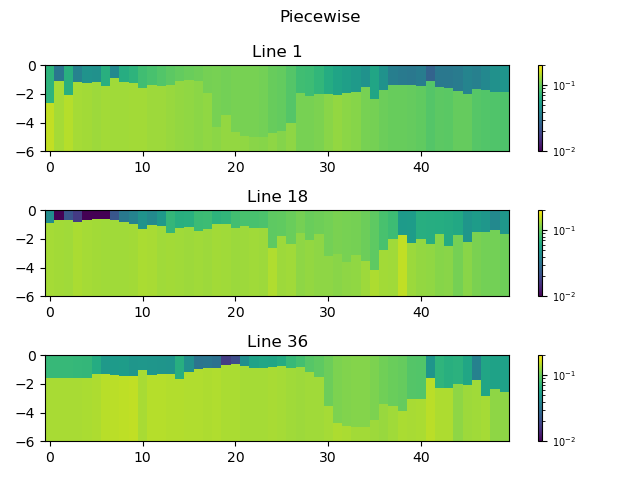

In [15]:
fig, ax = plt.subplots(3,1)

showStitchedModels(model_inv[:50], ax=ax[0], zMax=6, cMin=10/1000, cMax=200/1000)
ax[0].set_title('Line 1')

showStitchedModels(model_inv[900:950], ax=ax[1], zMax=6, cMin=10/1000, cMax=200/1000)
ax[1].set_title('Line 18')

showStitchedModels(model_inv[1800:], ax=ax[2], zMax=6, cMin=10/1000, cMax=200/1000)
ax[2].set_title('Line 36')

fig.suptitle('Piecewise')

plt.tight_layout()

In [12]:
X = Dataframe['X']
Y = Dataframe['Y']
h_1 = Model_inv_frame['h_1']
s_1 = Model_inv_frame['s_1']*1000
s_2 = Model_inv_frame['s_2']*1000

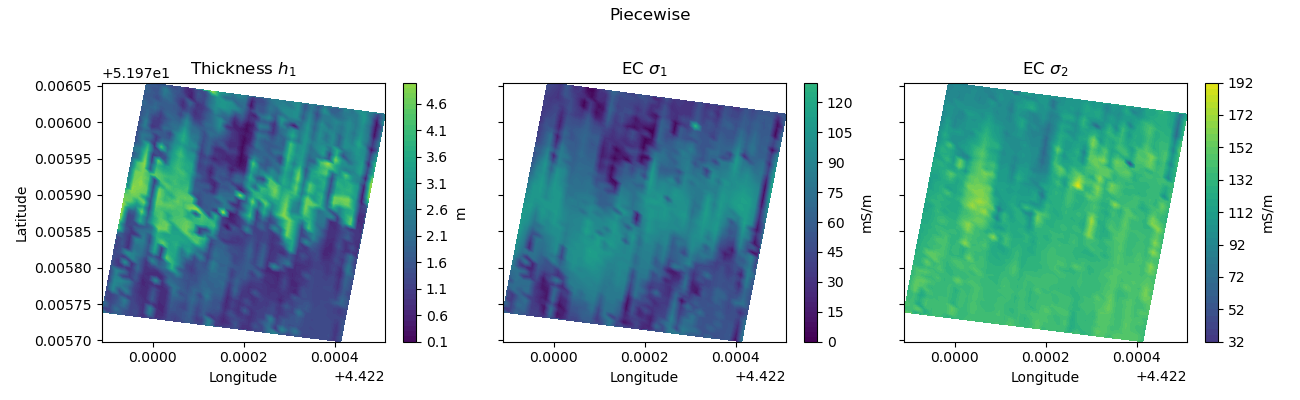

In [16]:


fig, ax = plt.subplots(1,3, figsize=(13,4), sharey=True)

cb0 = ax[0].tricontourf(X, Y, h_1, vmin=0, vmax=6, levels=50, cmap='viridis')
ax[0].set_title('Thickness $h_1$')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')


cb1 = ax[1].tricontourf(X, Y, s_1, vmin=1, vmax=200, levels=50, cmap='viridis')
ax[1].set_title('EC $\sigma_1$')
ax[1].set_xlabel('Longitude')

cb2 = ax[2].tricontourf(X, Y, s_2, vmin=1, vmax=200, levels=50, cmap='viridis')
ax[2].set_title('EC $\sigma_2$')
ax[2].set_xlabel('Longitude')

fig.colorbar(cb0, ax=ax[0], label='m')
fig.colorbar(cb1, ax=ax[1], label='mS/m')
fig.colorbar(cb2, ax=ax[2], label='mS/m')

fig.suptitle('Piecewise')

plt.tight_layout()
